In [3]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

In [4]:
clients = pd.read_csv("clients.csv")
properties = pd.read_csv("properties.csv")

In [5]:
clients.head()

,client_id,client_type,first_name,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel
0,C0001,Individual,Kareem,Liu,05-11-1968,F,USA,California,Home,4,Yes,Website
1,C0002,Individual,Trystan,Oconnor,11/26/1962,M,USA,California,Home,1,No,Website
2,C0003,Individual,Kale,Gay,04-07-1959,M,USA,California,Home,4,Yes,Agency
3,C0004,Individual,Russell,Gross,11/25/1959,M,USA,California,Home,5,No,Website
4,C0005,Company,Marleez,Co,2/28/1976,M,USA,California,Investment,5,No,Website


In [6]:
properties.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref
0,1012,1,01-01-2024,Apartment,12,1160.36,"$300,385.62",Sold,C0027
1,1015,1,01-01-2024,Apartment,15,782.25,"$208,930.81",Sold,C0097
2,1021,1,01-01-2024,Apartment,21,756.21,"$218,585.92",Sold,C0113
3,1030,1,01-01-2024,Apartment,30,743.09,"$246,172.68",Sold,C0141
4,2016,2,01-01-2024,Apartment,16,701.66,"$212,265.67",Sold,C0146


In [7]:
print("Clients Dataset Shape:", clients.shape)
print("Properties Dataset Shape:", properties.shape)

Clients Dataset Shape: (2000, 12)
Properties Dataset Shape: (10000, 9)


In [8]:
print("Clients Dataset Columns:")
print(clients.columns)

print("\nProperties Dataset Columns:")
print(properties.columns)

Clients Dataset Columns:
Index(['client_id', 'client_type', 'first_name', 'last_name', 'date_of_birth',
       'gender', 'country', 'region', 'acquisition_purpose',
       'satisfaction_score', 'loan_applied', 'referral_channel'],
      dtype='object')

Properties Dataset Columns:
Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref'],
      dtype='object')


In [9]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 12 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   client_id            2000 non-null   object
 1   client_type          2000 non-null   object
 2   first_name           2000 non-null   object
 3   last_name            2000 non-null   object
 4   date_of_birth        2000 non-null   object
 5   gender               2000 non-null   object
 6   country              2000 non-null   object
 7   region               2000 non-null   object
 8   acquisition_purpose  2000 non-null   object
 9   satisfaction_score   2000 non-null   int64 
 10  loan_applied         2000 non-null   object
 11  referral_channel     2000 non-null   object
dtypes: int64(1), object(11)
memory usage: 187.6+ KB


In [10]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [11]:
clients.isnull().sum()

client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
dtype: int64

In [12]:
properties.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref          2695
dtype: int64

In [13]:
print("Duplicate rows in Clients:", clients.duplicated().sum())
print("Duplicate rows in Properties:", properties.duplicated().sum())

Duplicate rows in Clients: 0
Duplicate rows in Properties: 0


In [14]:
clients = clients.drop_duplicates()

properties = properties.drop_duplicates()

In [15]:
print("Clients Shape:", clients.shape)

Clients Shape: (2000, 12)


In [16]:
print("Properties Shape:", properties.shape)

Properties Shape: (10000, 9)


In [17]:
clients.dtypes

client_id              object
client_type            object
first_name             object
last_name              object
date_of_birth          object
gender                 object
country                object
region                 object
acquisition_purpose    object
satisfaction_score      int64
loan_applied           object
referral_channel       object
dtype: object

In [18]:
properties.dtypes

listing_id            int64
tower_number          int64
transaction_date     object
unit_category        object
unit_number           int64
floor_area_sqft     float64
sale_price           object
listing_status       object
client_ref           object
dtype: object

In [20]:
clients["date_of_birth"] = pd.to_datetime(clients["date_of_birth"],format="mixed")

In [21]:
clients["Age"] = pd.Timestamp.today().year - clients["date_of_birth"].dt.year

In [22]:
clients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   client_id            2000 non-null   object        
 1   client_type          2000 non-null   object        
 2   first_name           2000 non-null   object        
 3   last_name            2000 non-null   object        
 4   date_of_birth        2000 non-null   datetime64[ns]
 5   gender               2000 non-null   object        
 6   country              2000 non-null   object        
 7   region               2000 non-null   object        
 8   acquisition_purpose  2000 non-null   object        
 9   satisfaction_score   2000 non-null   int64         
 10  loan_applied         2000 non-null   object        
 11  referral_channel     2000 non-null   object        
 12  Age                  2000 non-null   int32         
dtypes: datetime64[ns](1), int32(1), i

In [23]:
properties.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   listing_id        10000 non-null  int64  
 1   tower_number      10000 non-null  int64  
 2   transaction_date  10000 non-null  object 
 3   unit_category     10000 non-null  object 
 4   unit_number       10000 non-null  int64  
 5   floor_area_sqft   10000 non-null  float64
 6   sale_price        10000 non-null  object 
 7   listing_status    10000 non-null  object 
 8   client_ref        7305 non-null   object 
dtypes: float64(1), int64(3), object(5)
memory usage: 703.2+ KB


In [24]:
clients["Age"] = (
    pd.Timestamp.now().year
    - clients["date_of_birth"].dt.year
)

In [25]:
clients[["date_of_birth", "Age"]].head()

,date_of_birth,Age
0,1968-05-11,58
1,1962-11-26,64
2,1959-04-07,67
3,1959-11-25,67
4,1976-02-28,50


In [27]:
properties["transaction_date"].dtype

dtype('O')

In [33]:
properties["transaction_date"].head(10)

0   2024-01-01
1   2024-01-01
2   2024-01-01
3   2024-01-01
4   2024-01-01
5   2024-01-01
6   2024-01-01
7   2024-01-01
8   2024-01-01
9   2024-01-01
Name: transaction_date, dtype: datetime64[ns]

In [34]:
properties["transaction_date"] = pd.to_datetime(
    properties["transaction_date"],
    format="%d-%m-%Y"
)

In [35]:
properties["transaction_date"].dtype

dtype('<M8[ns]')

In [36]:
properties["Year"] = properties["transaction_date"].dt.year
properties["Month"] = properties["transaction_date"].dt.month_name()

In [37]:
properties[["transaction_date", "Year", "Month"]].head()

,transaction_date,Year,Month
0,2024-01-01,2024,January
1,2024-01-01,2024,January
2,2024-01-01,2024,January
3,2024-01-01,2024,January
4,2024-01-01,2024,January


In [38]:
df = pd.merge(properties,clients,left_on="client_ref",right_on="client_id",how="left")

In [39]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Year,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027,2024,...,Weber,1968-09-08,M,USA,California,Home,5.0,Yes,Website,58.0
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097,2024,...,Mack,1943-06-18,M,USA,Virginia,Home,5.0,Yes,Website,83.0
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113,2024,...,Bray,1949-07-14,M,USA,Utah,Investment,4.0,No,Agency,77.0
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141,2024,...,Mercer,1986-06-21,F,USA,California,Home,5.0,No,Website,40.0
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146,2024,...,Ayers,1963-02-01,M,USA,Colorado,Home,2.0,No,Website,63.0


In [40]:
df.shape

(10000, 24)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   listing_id           10000 non-null  int64         
 1   tower_number         10000 non-null  int64         
 2   transaction_date     10000 non-null  datetime64[ns]
 3   unit_category        10000 non-null  object        
 4   unit_number          10000 non-null  int64         
 5   floor_area_sqft      10000 non-null  float64       
 6   sale_price           10000 non-null  object        
 7   listing_status       10000 non-null  object        
 8   client_ref           7305 non-null   object        
 9   Year                 10000 non-null  int32         
 10  Month                10000 non-null  object        
 11  client_id            7305 non-null   object        
 12  client_type          7305 non-null   object        
 13  first_name           7305 non-nu

In [43]:
df.to_csv("cleaned_data.csv", index=False)

In [44]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Year,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027,2024,...,Weber,1968-09-08,M,USA,California,Home,5.0,Yes,Website,58.0
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097,2024,...,Mack,1943-06-18,M,USA,Virginia,Home,5.0,Yes,Website,83.0
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113,2024,...,Bray,1949-07-14,M,USA,Utah,Investment,4.0,No,Agency,77.0
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141,2024,...,Mercer,1986-06-21,F,USA,California,Home,5.0,No,Website,40.0
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146,2024,...,Ayers,1963-02-01,M,USA,Colorado,Home,2.0,No,Website,63.0


In [45]:
df.shape

(10000, 24)

In [46]:
df.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref', 'Year', 'Month', 'client_id', 'client_type', 'first_name',
       'last_name', 'date_of_birth', 'gender', 'country', 'region',
       'acquisition_purpose', 'satisfaction_score', 'loan_applied',
       'referral_channel', 'Age'],
      dtype='object')

In [47]:
df.describe()

,listing_id,tower_number,transaction_date,unit_number,floor_area_sqft,Year,date_of_birth,satisfaction_score,Age
count,10000.000000,10000.000000,10000,10000.00000,10000.000000,10000.000000,7305,7305.000000,7305.000000
mean,105898.277400,10.370100,2024-11-07 13:03:47.520000,28.99920,1139.941412,2024.398600,1970-01-25 03:48:04.435318275,3.051745,56.429979
min,1002.000000,1.000000,2024-01-01 00:00:00,1.00000,410.710000,2024.000000,1931-02-13 00:00:00,1.000000,26.000000
25%,50389.750000,5.000000,2024-05-01 00:00:00,15.00000,782.200000,2024.000000,1955-10-16 00:00:00,2.000000,42.000000
50%,100404.500000,10.000000,2024-10-01 00:00:00,29.00000,1110.880000,2024.000000,1969-07-15 00:00:00,3.000000,57.000000
75%,150411.250000,15.000000,2025-05-01 00:00:00,43.00000,1499.000000,2025.000000,1984-06-23 00:00:00,4.000000,71.000000
max,990026.000000,20.000000,2025-12-01 00:00:00,70.00000,1957.160000,2025.000000,2000-12-19 00:00:00,5.000000,95.000000
std,74414.566199,5.769025,NaN,16.88242,418.373967,0.489635,NaN,1.416073,17.242680


In [48]:
df.describe(include='object')

,unit_category,sale_price,listing_status,client_ref,Month,client_id,client_type,first_name,last_name,gender,country,region,acquisition_purpose,loan_applied,referral_channel
count,10000,10000,10000,7305,10000,7305,7305,7305,7305,7305,7305,7305,7305,7305,7305
unique,2,9998,2,2000,12,2000,2,337,224,2,10,57,2,2,3
top,Apartment,"$460,001.26",Sold,C0005,July,C0005,Individual,Carl,Co,M,USA,California,Home,No,Website
freq,8547,2,7305,13,885,13,6924,87,381,3723,5656,2399,5058,4621,4063


In [49]:
df.isnull().sum()

listing_id                0
tower_number              0
transaction_date          0
unit_category             0
unit_number               0
floor_area_sqft           0
sale_price                0
listing_status            0
client_ref             2695
Year                      0
Month                     0
client_id              2695
client_type            2695
first_name             2695
last_name              2695
date_of_birth          2695
gender                 2695
country                2695
region                 2695
acquisition_purpose    2695
satisfaction_score     2695
loan_applied           2695
referral_channel       2695
Age                    2695
dtype: int64

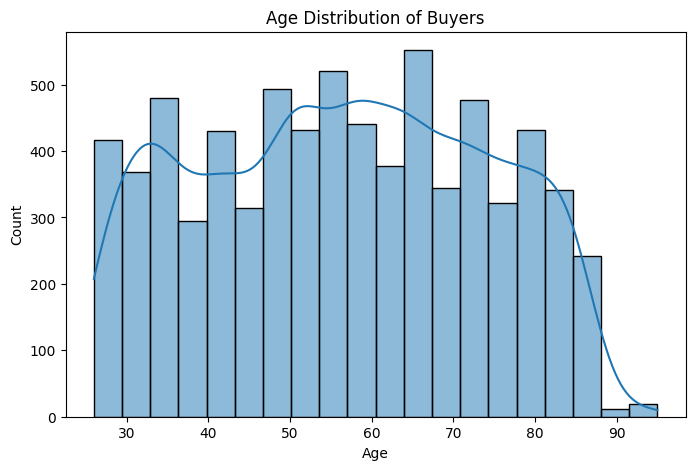

In [50]:
plt.figure(figsize=(8,5))
sns.histplot(df["Age"], bins=20, kde=True)
plt.title("Age Distribution of Buyers")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

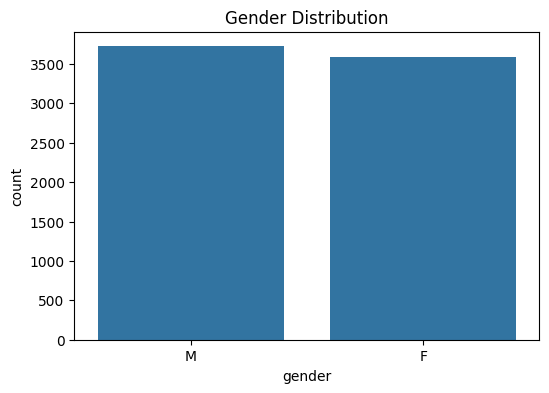

In [51]:
plt.figure(figsize=(6,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()

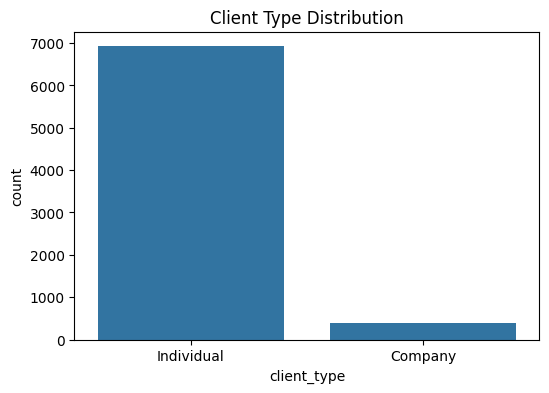

In [52]:
plt.figure(figsize=(6,4))
sns.countplot(x="client_type", data=df)
plt.title("Client Type Distribution")
plt.show()

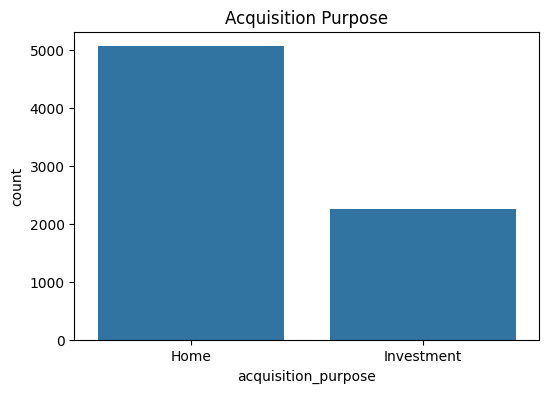

In [53]:
plt.figure(figsize=(6,4))
sns.countplot(x="acquisition_purpose", data=df)
plt.title("Acquisition Purpose")
plt.show()

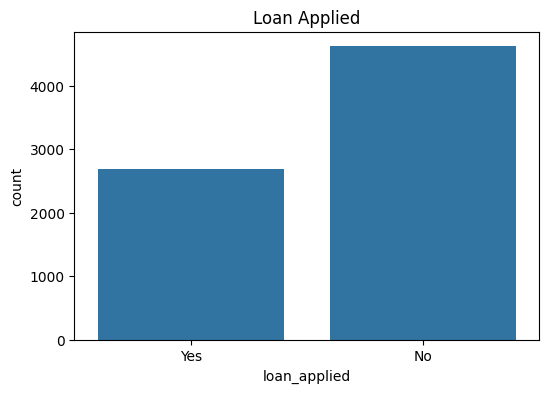

In [54]:
plt.figure(figsize=(6,4))
sns.countplot(x="loan_applied", data=df)
plt.title("Loan Applied")
plt.show()

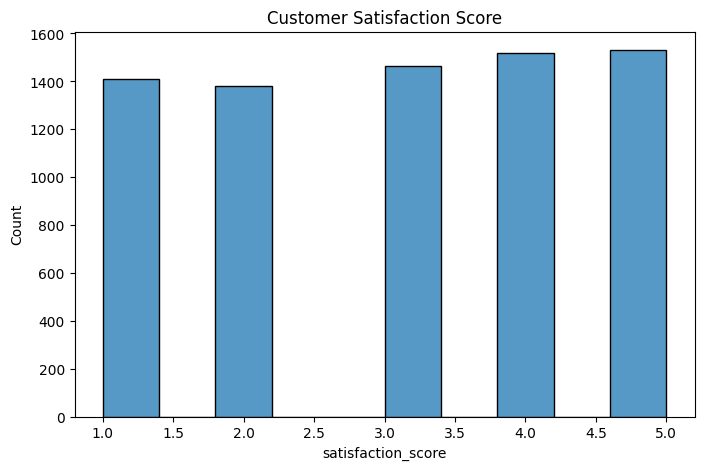

In [55]:
plt.figure(figsize=(8,5))
sns.histplot(df["satisfaction_score"], bins=10)
plt.title("Customer Satisfaction Score")
plt.show()

In [56]:
ml_data = df[["client_type","gender","country","region","acquisition_purpose","loan_applied","referral_channel","satisfaction_score","Age"]]

In [57]:
ml_data.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,Age
0,Individual,M,USA,California,Home,Yes,Website,5.0,58.0
1,Individual,M,USA,Virginia,Home,Yes,Website,5.0,83.0
2,Individual,M,USA,Utah,Investment,No,Agency,4.0,77.0
3,Individual,F,USA,California,Home,No,Website,5.0,40.0
4,Individual,M,USA,Colorado,Home,No,Website,2.0,63.0


In [58]:
ml_data.isnull().sum()

client_type            2695
gender                 2695
country                2695
region                 2695
acquisition_purpose    2695
loan_applied           2695
referral_channel       2695
satisfaction_score     2695
Age                    2695
dtype: int64

In [59]:
ml_data = ml_data.dropna()

In [60]:
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler

In [61]:
le = LabelEncoder()

In [62]:
ml_data["client_type"] = le.fit_transform(ml_data["client_type"])
ml_data["gender"] = le.fit_transform(ml_data["gender"])
ml_data["country"] = le.fit_transform(ml_data["country"])
ml_data["region"] = le.fit_transform(ml_data["region"])
ml_data["acquisition_purpose"] = le.fit_transform(ml_data["acquisition_purpose"])
ml_data["loan_applied"] = le.fit_transform(ml_data["loan_applied"])
ml_data["referral_channel"] = le.fit_transform(ml_data["referral_channel"])

In [63]:
ml_data.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,Age
0,1,1,9,8,0,1,2,5.0,58.0
1,1,1,9,50,0,1,2,5.0,83.0
2,1,1,9,48,1,0,0,4.0,77.0
3,1,0,9,8,0,0,2,5.0,40.0
4,1,1,9,11,0,0,2,2.0,63.0


In [64]:
scaler = StandardScaler()

In [65]:
scaled_data = scaler.fit_transform(ml_data)

In [66]:
scaled_df = pd.DataFrame(scaled_data,columns=ml_data.columns)

In [67]:
scaled_df.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,Age
0,0.234576,0.980881,0.449909,-0.778695,-0.666518,1.31213,0.853552,1.375909,0.091061
1,0.234576,0.980881,0.449909,1.745194,-0.666518,1.31213,0.853552,1.375909,1.541050
2,0.234576,0.980881,0.449909,1.625009,1.500334,-0.76212,-1.301346,0.669683,1.193053
3,0.234576,-1.019492,0.449909,-0.778695,-0.666518,-0.76212,0.853552,1.375909,-0.952932
4,0.234576,0.980881,0.449909,-0.598417,-0.666518,-0.76212,0.853552,-0.742771,0.381059


In [68]:
scaled_df.describe()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,satisfaction_score,Age
count,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03,7.305000e+03
mean,-4.766132e-17,6.419688e-17,-3.598916e-17,-3.112576e-17,6.662858e-17,7.927342e-17,5.057936e-17,9.848385e-17,2.042628e-16
std,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00,1.000068e+00
min,-4.263007e+00,-1.019492e+00,-3.413628e+00,-1.259435e+00,-6.665184e-01,-7.621198e-01,-1.301346e+00,-1.448997e+00,-1.764926e+00
25%,2.345762e-01,-1.019492e+00,4.499086e-01,-7.786947e-01,-6.665184e-01,-7.621198e-01,-1.301346e+00,-7.427706e-01,-8.369329e-01
50%,2.345762e-01,9.808809e-01,4.499086e-01,-5.383243e-01,-6.665184e-01,-7.621198e-01,8.535517e-01,-3.654396e-02,3.306096e-02
75%,2.345762e-01,9.808809e-01,4.499086e-01,9.639905e-01,1.500334e+00,1.312130e+00,8.535517e-01,6.696826e-01,8.450553e-01
max,2.345762e-01,9.808809e-01,4.499086e-01,2.105750e+00,1.500334e+00,1.312130e+00,8.535517e-01,1.375909e+00,2.237046e+00


In [69]:
df = pd.merge(properties,clients,left_on="client_ref",right_on="client_id",how="left")

In [70]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Year,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age
0,1012,1,2024-01-01,Apartment,12,1160.36,"$300,385.62",Sold,C0027,2024,...,Weber,1968-09-08,M,USA,California,Home,5.0,Yes,Website,58.0
1,1015,1,2024-01-01,Apartment,15,782.25,"$208,930.81",Sold,C0097,2024,...,Mack,1943-06-18,M,USA,Virginia,Home,5.0,Yes,Website,83.0
2,1021,1,2024-01-01,Apartment,21,756.21,"$218,585.92",Sold,C0113,2024,...,Bray,1949-07-14,M,USA,Utah,Investment,4.0,No,Agency,77.0
3,1030,1,2024-01-01,Apartment,30,743.09,"$246,172.68",Sold,C0141,2024,...,Mercer,1986-06-21,F,USA,California,Home,5.0,No,Website,40.0
4,2016,2,2024-01-01,Apartment,16,701.66,"$212,265.67",Sold,C0146,2024,...,Ayers,1963-02-01,M,USA,Colorado,Home,2.0,No,Website,63.0


In [71]:
df.shape

(10000, 24)

In [72]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   listing_id           10000 non-null  int64         
 1   tower_number         10000 non-null  int64         
 2   transaction_date     10000 non-null  datetime64[ns]
 3   unit_category        10000 non-null  object        
 4   unit_number          10000 non-null  int64         
 5   floor_area_sqft      10000 non-null  float64       
 6   sale_price           10000 non-null  object        
 7   listing_status       10000 non-null  object        
 8   client_ref           7305 non-null   object        
 9   Year                 10000 non-null  int32         
 10  Month                10000 non-null  object        
 11  client_id            7305 non-null   object        
 12  client_type          7305 non-null   object        
 13  first_name           7305 non-nu

In [73]:
df.isnull().sum()

listing_id                0
tower_number              0
transaction_date          0
unit_category             0
unit_number               0
floor_area_sqft           0
sale_price                0
listing_status            0
client_ref             2695
Year                      0
Month                     0
client_id              2695
client_type            2695
first_name             2695
last_name              2695
date_of_birth          2695
gender                 2695
country                2695
region                 2695
acquisition_purpose    2695
satisfaction_score     2695
loan_applied           2695
referral_channel       2695
Age                    2695
dtype: int64

In [74]:
df[df["client_id"].isnull()].head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Year,...,last_name,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age
11,4039,4,2024-01-01,Apartment,39,785.48,"$216,826.00",Available,NaN,2024,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
12,5015,5,2024-01-01,Apartment,15,798.50,"$237,680.88",Available,NaN,2024,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19,10035,1,2024-01-01,Apartment,4,633.61,"$166,623.12",Available,NaN,2024,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
20,10052,1,2024-01-01,Apartment,6,740.75,"$233,361.41",Available,NaN,2024,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
27,10186,1,2024-01-01,Office,23,1201.50,"$399,122.68",Available,NaN,2024,...,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [75]:
df = df.dropna(subset=["client_ref"])

In [76]:
df.isnull().sum()

listing_id             0
tower_number           0
transaction_date       0
unit_category          0
unit_number            0
floor_area_sqft        0
sale_price             0
listing_status         0
client_ref             0
Year                   0
Month                  0
client_id              0
client_type            0
first_name             0
last_name              0
date_of_birth          0
gender                 0
country                0
region                 0
acquisition_purpose    0
satisfaction_score     0
loan_applied           0
referral_channel       0
Age                    0
dtype: int64

In [77]:
df["sale_price"].dtype

dtype('O')

In [78]:
df["sale_price"] = df["sale_price"].replace(r"[\$,]", "", regex=True)

In [79]:
df["sale_price"] = df["sale_price"].astype(float)

In [80]:
df["sale_price"].dtype

dtype('float64')

In [81]:
ml_data = df[[
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel",
    "Age",
    "satisfaction_score",
    "sale_price",
    "floor_area_sqft"
]]

In [82]:
ml_data.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,Age,satisfaction_score,sale_price,floor_area_sqft
0,Individual,M,USA,California,Home,Yes,Website,58.0,5.0,300385.62,1160.36
1,Individual,M,USA,Virginia,Home,Yes,Website,83.0,5.0,208930.81,782.25
2,Individual,M,USA,Utah,Investment,No,Agency,77.0,4.0,218585.92,756.21
3,Individual,F,USA,California,Home,No,Website,40.0,5.0,246172.68,743.09
4,Individual,M,USA,Colorado,Home,No,Website,63.0,2.0,212265.67,701.66


In [83]:
ml_data.isnull().sum()

client_type            0
gender                 0
country                0
region                 0
acquisition_purpose    0
loan_applied           0
referral_channel       0
Age                    0
satisfaction_score     0
sale_price             0
floor_area_sqft        0
dtype: int64

In [88]:
from sklearn.preprocessing import LabelEncoder

In [87]:
ml_data = df[[
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel",
    "Age",
    "satisfaction_score",
    "sale_price",
    "floor_area_sqft"
]].copy()

In [89]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

categorical_cols = [
    "client_type",
    "gender",
    "country",
    "region",
    "acquisition_purpose",
    "loan_applied",
    "referral_channel"
]

for col in categorical_cols:
    ml_data[col] = le.fit_transform(ml_data[col])

In [90]:
ml_data.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,Age,satisfaction_score,sale_price,floor_area_sqft
0,1,1,9,8,0,1,2,58.0,5.0,300385.62,1160.36
1,1,1,9,50,0,1,2,83.0,5.0,208930.81,782.25
2,1,1,9,48,1,0,0,77.0,4.0,218585.92,756.21
3,1,0,9,8,0,0,2,40.0,5.0,246172.68,743.09
4,1,1,9,11,0,0,2,63.0,2.0,212265.67,701.66


In [91]:
ml_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7305 entries, 0 to 9997
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   client_type          7305 non-null   int64  
 1   gender               7305 non-null   int64  
 2   country              7305 non-null   int64  
 3   region               7305 non-null   int64  
 4   acquisition_purpose  7305 non-null   int64  
 5   loan_applied         7305 non-null   int64  
 6   referral_channel     7305 non-null   int64  
 7   Age                  7305 non-null   float64
 8   satisfaction_score   7305 non-null   float64
 9   sale_price           7305 non-null   float64
 10  floor_area_sqft      7305 non-null   float64
dtypes: float64(4), int64(7)
memory usage: 684.8 KB


In [92]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
scaled_data = scaler.fit_transform(ml_data)
scaled_df = pd.DataFrame(scaled_data, columns=ml_data.columns)
scaled_df.head()

,client_type,gender,country,region,acquisition_purpose,loan_applied,referral_channel,Age,satisfaction_score,sale_price,floor_area_sqft
0,0.234576,0.980881,0.449909,-0.778695,-0.666518,1.31213,0.853552,0.091061,1.375909,-0.338419,0.045829
1,0.234576,0.980881,0.449909,1.745194,-0.666518,1.31213,0.853552,1.541050,1.375909,-1.031023,-0.856123
2,0.234576,0.980881,0.449909,1.625009,1.500334,-0.76212,-1.301346,1.193053,0.669683,-0.957903,-0.918239
3,0.234576,-1.019492,0.449909,-0.778695,-0.666518,-0.76212,0.853552,-0.952932,1.375909,-0.748983,-0.949536
4,0.234576,0.980881,0.449909,-0.598417,-0.666518,-0.76212,0.853552,0.381059,-0.742771,-1.005768,-1.048364


In [93]:
from sklearn.cluster import KMeans

In [95]:
wcss = []

for i in range(1, 11):
    kmeans = KMeans(
        n_clusters=i,
        init='k-means++',
        random_state=42,
        n_init=10
    )
    kmeans.fit(scaled_df)
    wcss.append(kmeans.inertia_)

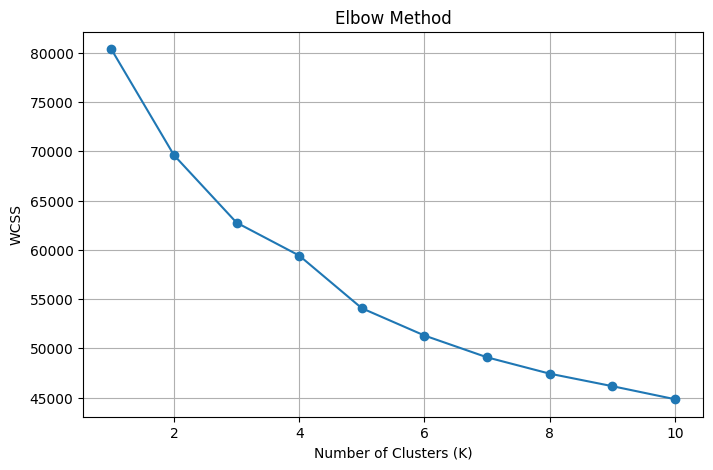

In [96]:
plt.figure(figsize=(8,5))

plt.plot(range(1,11), wcss, marker='o')

plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("WCSS")

plt.grid(True)

plt.show()

In [97]:
kmeans = KMeans(
    n_clusters=5,
    init="k-means++",
    random_state=42,
    n_init=10
)

clusters = kmeans.fit_predict(scaled_df)

In [98]:
df["Cluster"] = clusters

In [99]:
df.head()

,listing_id,tower_number,transaction_date,unit_category,unit_number,floor_area_sqft,sale_price,listing_status,client_ref,Year,...,date_of_birth,gender,country,region,acquisition_purpose,satisfaction_score,loan_applied,referral_channel,Age,Cluster
0,1012,1,2024-01-01,Apartment,12,1160.36,300385.62,Sold,C0027,2024,...,1968-09-08,M,USA,California,Home,5.0,Yes,Website,58.0,1
1,1015,1,2024-01-01,Apartment,15,782.25,208930.81,Sold,C0097,2024,...,1943-06-18,M,USA,Virginia,Home,5.0,Yes,Website,83.0,1
2,1021,1,2024-01-01,Apartment,21,756.21,218585.92,Sold,C0113,2024,...,1949-07-14,M,USA,Utah,Investment,4.0,No,Agency,77.0,2
3,1030,1,2024-01-01,Apartment,30,743.09,246172.68,Sold,C0141,2024,...,1986-06-21,F,USA,California,Home,5.0,No,Website,40.0,1
4,2016,2,2024-01-01,Apartment,16,701.66,212265.67,Sold,C0146,2024,...,1963-02-01,M,USA,Colorado,Home,2.0,No,Website,63.0,1


In [100]:
df["Cluster"].value_counts()

Cluster
1    2553
3    2261
2    1343
0     767
4     381
Name: count, dtype: int64

In [101]:
from sklearn.metrics import silhouette_score

score = silhouette_score(scaled_df, clusters)

print("Silhouette Score:", score)

Silhouette Score: 0.13685226638062342


In [102]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "sale_price",
    "floor_area_sqft",
    "satisfaction_score"
]].mean()

cluster_summary

,Age,sale_price,floor_area_sqft,satisfaction_score
Cluster,,,,
0,54.428944,334341.758083,1114.516923,3.112125
1,58.020368,255056.571606,852.578343,3.033294
2,56.247208,274386.669739,913.359903,3.026061
3,56.784166,492916.186541,1613.001641,3.055285
4,48.343832,341644.645276,1131.178241,3.123360


In [103]:
df.groupby("Cluster")["client_type"].value_counts()

Cluster  client_type
0        Individual      767
1        Individual     2553
2        Individual     1343
3        Individual     2261
4        Company         381
Name: count, dtype: int64

In [104]:
df.groupby("Cluster")["acquisition_purpose"].value_counts()

Cluster  acquisition_purpose
0        Home                    539
         Investment              228
1        Home                   2553
2        Investment             1343
3        Home                   1731
         Investment              530
4        Home                    235
         Investment              146
Name: count, dtype: int64

In [105]:
df.groupby("Cluster")["loan_applied"].value_counts()

Cluster  loan_applied
0        No               515
         Yes              252
1        No              1598
         Yes              955
2        No               844
         Yes              499
3        No              1433
         Yes              828
4        No               231
         Yes              150
Name: count, dtype: int64

In [106]:
df.groupby("Cluster")["country"].value_counts()

Cluster  country  
0        Canada        287
         Belgium       158
         Australia     126
         France        114
         Denmark        46
         Germany        36
1        USA          2251
         UK            134
         Russia         58
         Germany        54
         Mexico         50
         France          6
2        USA          1163
         UK             64
         Germany        38
         Mexico         38
         Russia         24
         France         16
3        USA          1942
         UK            131
         Germany        57
         Mexico         45
         Russia         43
         France         35
         Denmark         6
         Canada          2
4        USA           300
         UK             19
         France         16
         Canada         11
         Mexico         11
         Germany        10
         Australia       7
         Belgium         4
         Russia          3
Name: count, dtype: int64

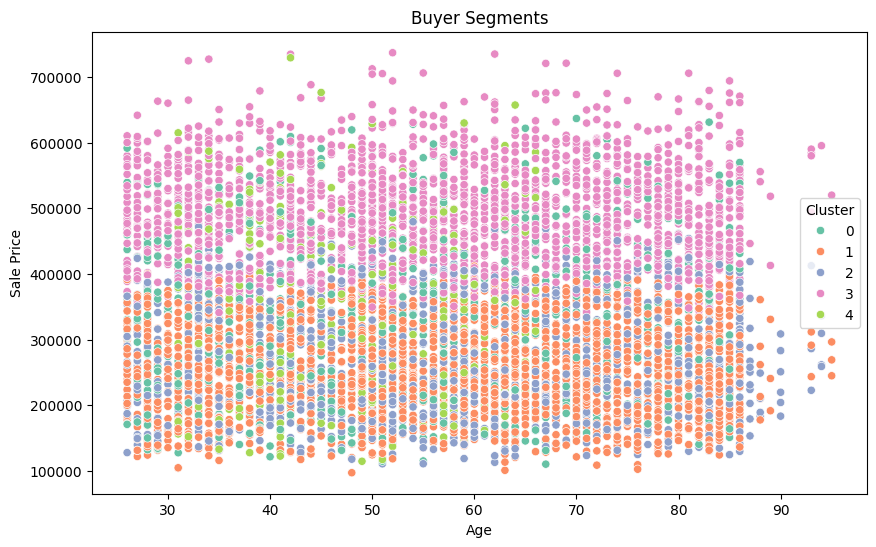

In [107]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x="Age",
    y="sale_price",
    hue="Cluster",
    palette="Set2"
)

plt.title("Buyer Segments")
plt.xlabel("Age")
plt.ylabel("Sale Price")
plt.show()

In [108]:
df.to_csv("buyer_segments.csv", index=False)

In [109]:
df["Cluster"].value_counts().sort_index()

Cluster
0     767
1    2553
2    1343
3    2261
4     381
Name: count, dtype: int64

In [110]:
cluster_summary = df.groupby("Cluster")[[
    "Age",
    "sale_price",
    "floor_area_sqft",
    "satisfaction_score"
]].mean()

cluster_summary

,Age,sale_price,floor_area_sqft,satisfaction_score
Cluster,,,,
0,54.428944,334341.758083,1114.516923,3.112125
1,58.020368,255056.571606,852.578343,3.033294
2,56.247208,274386.669739,913.359903,3.026061
3,56.784166,492916.186541,1613.001641,3.055285
4,48.343832,341644.645276,1131.178241,3.123360


In [111]:
df.columns

Index(['listing_id', 'tower_number', 'transaction_date', 'unit_category',
       'unit_number', 'floor_area_sqft', 'sale_price', 'listing_status',
       'client_ref', 'Year', 'Month', 'client_id', 'client_type', 'first_name',
       'last_name', 'date_of_birth', 'gender', 'country', 'region',
       'acquisition_purpose', 'satisfaction_score', 'loan_applied',
       'referral_channel', 'Age', 'Cluster'],
      dtype='object')

In [112]:
cluster_names = {
    0: "Premium Home Buyers",
    1: "Budget Buyers",
    2: "Mid-Range Investors",
    3: "Luxury Investors",
    4: "Young Premium Buyers"
}

df["Buyer_Segment"] = df["Cluster"].map(cluster_names)

In [113]:
df[["Cluster", "Buyer_Segment"]].head()

,Cluster,Buyer_Segment
0,1,Budget Buyers
1,1,Budget Buyers
2,2,Mid-Range Investors
3,1,Budget Buyers
4,1,Budget Buyers


In [114]:
df.to_csv(r"G:\Buyer_Segmentation_Project\buyer_segmentation_final.csv", index=False)

In [116]:
ml_data["sale_price"] = ml_data["sale_price"].apply(lambda x: f"₹{x:,.0f}")